# 烂片网络

In [1]:
import pandas as pd
import numpy as np
import networkx as nx
import scipy
import matplotlib.pyplot as plt
plt.rcParams['font.sans-serif'] = ['Heiti TC']
plt.rcParams['axes.unicode_minus'] = False
from networkx.algorithms import bipartite
import json

In [2]:
import sys
sys.path.append("..")

# 数据处理

In [3]:
df_raw = pd.read_csv("../data/movie_data_rated.csv")
df_raw['k_cast_id'] = df_raw['k_cast_id'].apply(lambda x: str(x))
df_raw

,cast_id,cast_name,gender,movie_id,k_role,is_main_cast,index,id,k_title,k_type,...,rating_num,rating_people,k_rating_people,rating_index,k_movie_id,k_cast_id,uid,portray,movie_id_m,cast_role_agg
0,1017182,陈燕燕,女,10771202,演员,是,1,10771202,深闺疑云,电影,...,7.8,92,92.0,27.0,21542453,2034413,54,赵兰,m21542453,演员
1,1043845,刘志荣,男,10581318,演员,是,11,10581318,四大家族之龙虎兄弟,电影,...,7.8,2290,2290.0,134.0,21162685,2087739,75,NaN,m21162685,导演/演员
2,1050373,茅瑛,女,10573512,演员,是,1,10573512,鬼娘子,电影,...,5.8,235,235.0,37.0,21147073,2100795,77,NaN,m21147073,演员
3,1124360,利智,女,10581318,演员,是,3,10581318,四大家族之龙虎兄弟,电影,...,7.8,2290,2290.0,134.0,21162685,2248769,92,NaN,m21162685,演员
4,1315281,卢庆辉,男,10490155,演员,是,1,10490155,衰鬼抓狂,电影,...,5.8,121,121.0,26.0,20980359,2630611,156,NaN,m20980359,演员
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
100882,27541325,张世,男,1298203,演员,是,2,1298203,国道封闭,电影,...,7.9,146,146.0,34.0,2596455,55082699,604105,NaN,m2596455,导演/演员
100883,27517568,林迪安,男,1300498,演员,否,999,1300498,百变星君,电影,...,7.7,246162,246162.0,1377.0,2601045,55035185,604118,穿斑马服君,m2601045,演员
100884,27541395,韩鹏翼,男,24695588,演员,是,2,24695588,逆袭,电影,...,5.1,674,674.0,59.0,49391225,55082839,604119,NaN,m49391225,演员
100885,27496534,刘芊蒂,女,2337597,演员,是,2,2337597,操行零分,电影,...,7.0,211,211.0,38.0,4675243,54993117,604128,NaN,m4675243,演员


In [29]:
df_movie = df_raw[['movie_id_m', 'k_title',
                   'rating_num', 'k_rating_people']].drop_duplicates().reset_index(drop=True)
df_movie

,movie_id_m,k_title,rating_num,k_rating_people
0,m21542453,深闺疑云,7.8,92.0
1,m21162685,四大家族之龙虎兄弟,7.8,2290.0
2,m21147073,鬼娘子,5.8,235.0
3,m20980359,衰鬼抓狂,5.8,121.0
4,m21480521,冬去春来,5.7,42.0
...,...,...,...,...
10297,m53335019,武则天降妖记,2.2,378.0
10298,m9414485,黑蛋，快跑,7.0,69.0
10299,m53623223,大护法,7.8,326831.0
10300,m70564915,大雨,6.3,27389.0


In [5]:
def get_G(df):
    G = nx.from_pandas_edgelist(
        df,
        source='k_cast_id',
        target='movie_id_m',
        edge_attr=True,
        create_using=nx.Graph()
    )
    return G

In [6]:
# 最大连通子图
def get_largest_connected_component(G):
    if nx.is_connected(G):
        return G
    else:
        largest_cc = max(nx.connected_components(G), key=len)
        return G.subgraph(largest_cc).copy()

In [7]:
# 二分图，投影到电影节点
def get_movie_bip(G, cast_ids):
    return bipartite.projected_graph(G, G.nodes - cast_ids)

In [8]:
def draw_movie_net(G):
    pos = nx.spring_layout(G, seed=42)

    plt.figure(figsize=(10, 10))
    nx.draw_networkx(
        G,
        pos=pos,
        with_labels=False,
        node_size=1,
        edge_color="gainsboro",
        alpha=0.4,
    )
    plt.title("Movie Network")
    plt.axis('off')
    plt.show()
    print(G.number_of_nodes(), G.number_of_edges())

In [ ]:
# 按评分提取数据
def get_lowest_rated_movie_casts(df_movie, df, ascending=True, top_n=100):
    df_movie_n = df_movie.sort_values(by='rating_num', ascending=ascending).head(top_n)
    df_n = df_movie_n[['movie_id_m']].merge(df,
                                            left_on='movie_id_m',
                                            right_on='movie_id_m',
                                            how='left')
    return df_n

In [42]:
# 度数为1的影人节点
def degree_1_cast_ids(G):
    degree_1_nodes = [node for node, degree in G.degree() if degree == 1]
    nodes_to_remove = [i for i in degree_1_nodes if 'm' not in str(i)]
    return nodes_to_remove

# TOP -N

In [32]:
df_n = get_lowest_rated_movie_casts(df_movie, df_raw, top_n=250)
df_n

,movie_id_m,cast_id,cast_name,gender,movie_id,k_role,is_main_cast,index,id,k_title,...,is_rating,rating_num,rating_people,k_rating_people,rating_index,k_movie_id,k_cast_id,uid,portray,cast_role_agg
0,m69786029,33383707,刘亦彤,女,34892990,演员,是,3,34892990,北平会馆,...,有评分,2.1,1537,1537.0,57.0,69786029,66767463,25315,简宁,演员
1,m69786029,34896054,彭朝辉,男,34892990,演员,是,6,34892990,北平会馆,...,有评分,2.1,1537,1537.0,57.0,69786029,69792157,117207,王麻子,演员
2,m69786029,1426830,周岳龙,男,34892990,演员,是,8,34892990,北平会馆,...,有评分,2.1,1537,1537.0,57.0,69786029,2853709,120193,许立元,演员
3,m69786029,1426824,吴大可,男,34892990,演员,是,1,34892990,北平会馆,...,有评分,2.1,1537,1537.0,57.0,69786029,2853697,209626,李天沫,演员
4,m69786029,34896055,段志峰,男,34892990,演员,是,7,34892990,北平会馆,...,有评分,2.1,1537,1537.0,57.0,69786029,69792159,253786,老六,演员
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1577,m53540769,27485295,文东俊,男,26770360,演员,是,2,26770360,比基尼惊魂夜,...,有评分,2.8,187,187.0,23.0,53540769,54970639,481553,NaN,演员
1578,m53540769,1381531,孙晟轩,男,26770360,演员,否,999,26770360,比基尼惊魂夜,...,有评分,2.8,187,187.0,23.0,53540769,2763111,582262,梓霆,演员
1579,m53278841,1433617,完颜羽珊,女,26639396,演员,是,1,26639396,阴婚之鬼压床,...,有评分,2.8,133,133.0,19.0,53278841,2867283,405844,NaN,演员
1580,m53278841,1406638,张蓝兮,女,26639396,演员,是,4,26639396,阴婚之鬼压床,...,有评分,2.8,133,133.0,19.0,53278841,2813325,478947,李娜,演员


In [ ]:
df_n.sort_values(by='rating_num', ascending=True)

## 全量

In [11]:
G_n = get_G(df_n)
G_n.number_of_nodes(), G_n.number_of_edges()

(1636, 1564)

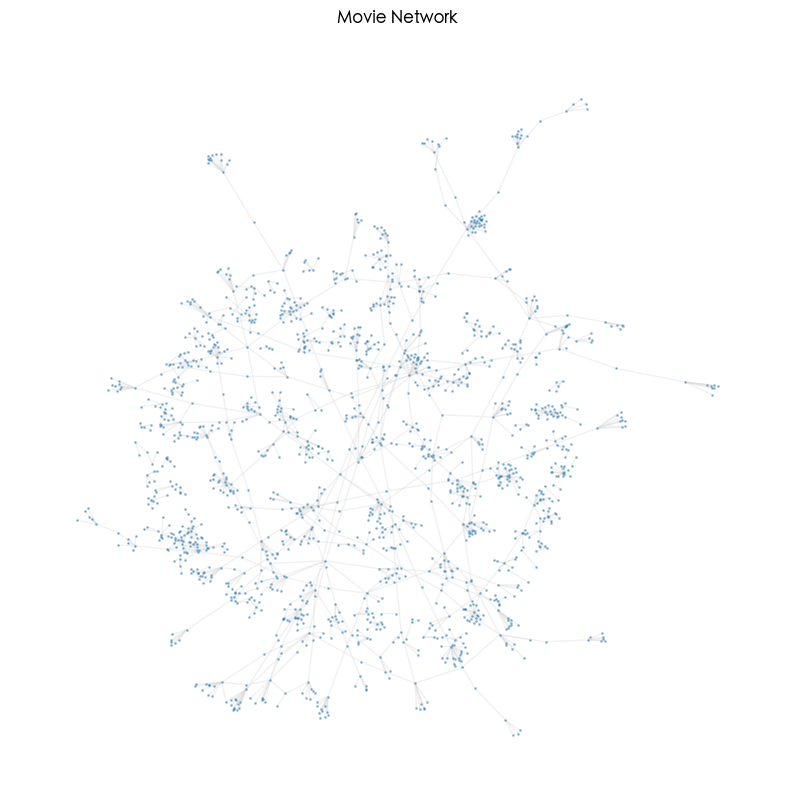

1636 1564


In [12]:
draw_movie_net(G_n)

## 全量-最大子图

In [13]:
G_n_largest = get_largest_connected_component(G_n)
G_n_largest.number_of_nodes(), G_n_largest.number_of_edges()

(856, 897)

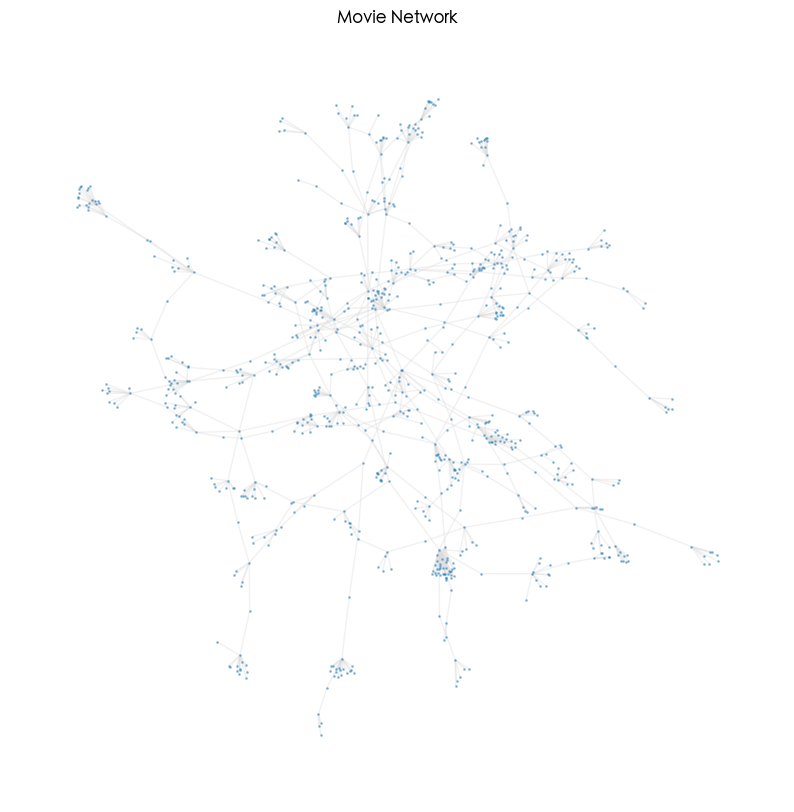

856 897


In [14]:
draw_movie_net(G_n_largest)

## 度数大于1节点图

In [16]:
G_n_node_to_remove = degree_1_cast_ids(G_n)
len(G_n_node_to_remove)

1252

In [17]:
G_n_d2 = G_n.copy()
G_n_d2.remove_nodes_from(G_n_node_to_remove)
G_n_d2.number_of_nodes(), G_n_d2.number_of_edges()

(384, 312)

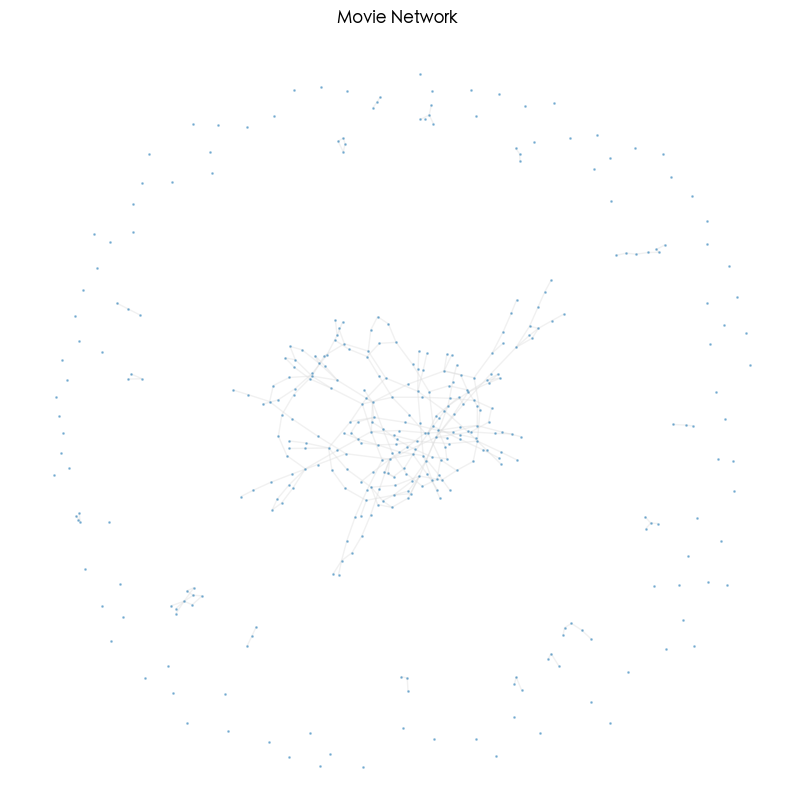

384 312


In [18]:
draw_movie_net(G_n_d2)

## 度数大于1节点图-最大子图

In [19]:
G_n_largest_node_to_remove = degree_1_cast_ids(G_n_largest)
len(G_n_largest_node_to_remove)

642

In [20]:
G_n_d2_largest = G_n_largest.copy()
G_n_d2_largest.remove_nodes_from(G_n_largest_node_to_remove)
G_n_d2_largest.number_of_nodes(), G_n_d2_largest.number_of_edges()

(214, 255)

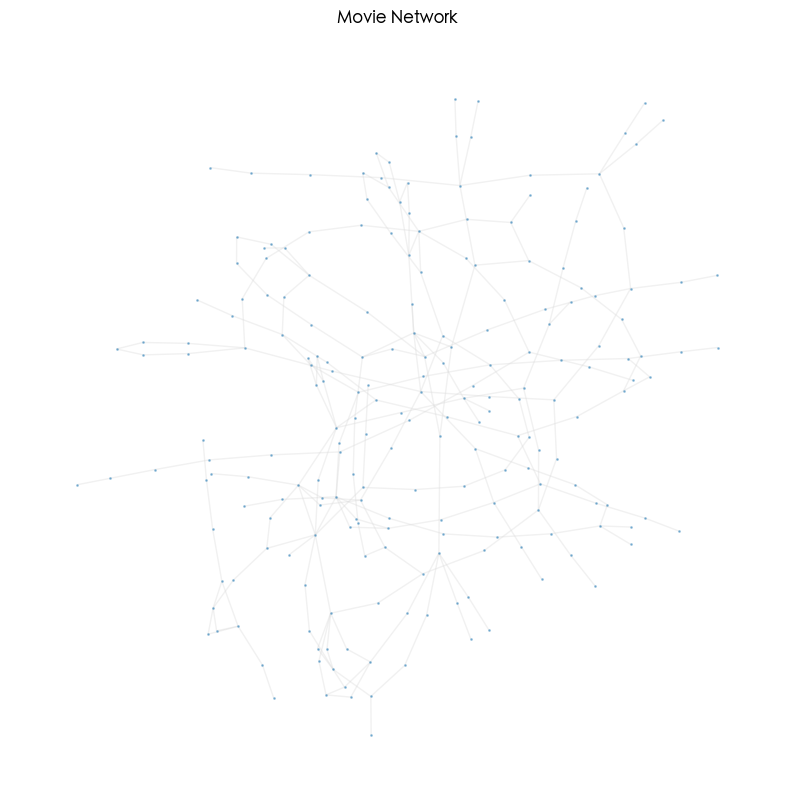

214 255


In [21]:
draw_movie_net(G_n_d2_largest)

## 数据

In [ ]:
def get_chart_data(G, df):
    nodes = G.nodes()
    pos = nx.spring_layout(G, seed=42)
    degrees = dict(G.degree())
    cast_degrees = {k: v for k, v in degrees.items() if 'm' not in str(k)}
    # 将cast_degrees归一到2-7的范围
    cast_degree_values = np.array(list(cast_degrees.values()))
    min_degree = cast_degree_values.min()
    max_degree = cast_degree_values.max()
    for key in cast_degrees:
        cast_degrees[key] = 2 + 5 * (cast_degrees[key] -
                                     min_degree) / (max_degree - min_degree) 
    # 二分图-电影
    movie_nodes = [n for n in nodes if 'm' in str(n)]
    G_movie = bipartite.projected_graph(G, movie_nodes)
    movie_degrees = dict(G_movie.degree())
    # 将movie_degrees归一到2-9的范围
    movie_degree_values = np.array(list(movie_degrees.values()))
    min_degree = movie_degree_values.min()
    max_degree = movie_degree_values.max()
    for key in movie_degrees:
        movie_degrees[key] = 2 + 7 * (movie_degrees[key] -
                                      min_degree) / (max_degree - min_degree)
    # 节点属性
    nodes_data = []
    movie_num = 0
    for node in nodes:
        node_pos = pos[node]
        node_data = {}
        if 'm' in str(node):
            node_data['category'] = '电影'
            node_data['title'] = df[df['movie_id_m'] ==
                                    node]['k_title'].values[0]
            node_data['degree'] = movie_degrees.get(node, 0)
            node_data['order'] = 0
            movie_num += 1
        else:
            node_data['category'] = '影人'
            node_data['title'] = df[df['k_cast_id'] ==
                                    node]['cast_name'].values[0]
            node_data['degree'] = cast_degrees.get(node, 0)
            node_data['order'] = 1
        node_data['id'] = str(node)
        node_data['x'] = round(float(node_pos[0]), 6)
        node_data['y'] = round(float(node_pos[1]) / 9 * 16, 6)
        nodes_data.append(node_data)
    # 边属性
    edges = G.edges()
    edges_data = [{
        'source': str(s),
        'target': str(t),
        'color': '#6BA3F7'
    } for s, t in edges]

    cast_num = len(nodes) - movie_num
    subtitle = f"{movie_num}部电影, {cast_num}位导演与主要演员"
    net_data = {
        'nodes': nodes_data,
        'edges': edges_data,
        'categories': [{
            'name': '电影',
            'order': 0
        }, {
            'name': '影人',
            'order': 1
        }],
        'subtitle': subtitle,
        'title': 0
    }
    return net_data

In [81]:
net_data = get_chart_data(G_n, df_n)
net_data['title'] = "低分电影关系网：豆瓣评分最低的250部电影"
net_data_largest = get_chart_data(G_n_largest, df_n)
net_data_largest['title'] = "低分电影关系网：最大连通子图"
net_data_d2 = get_chart_data(G_n_d2, df_n)
net_data_d2['title'] = "低分电影关系网：去除度为1影人节点"
net_data_d2_largest = get_chart_data(G_n_d2_largest, df_n)
net_data_d2_largest['title'] = "低分电影关系网：最大连通子图，去除度为1影人节点"

In [82]:
net_data = {"net_data": net_data,
            "net_data_largest": net_data_largest,
            "net_data_d2": net_data_d2,
            "net_data_d2_largest": net_data_d2_largest,
            }

In [83]:
# 保存处理后的数据
with open('json_data/movie_net_data_lowest.json', 'w', encoding='utf-8') as f:
    json.dump(net_data, f, ensure_ascii=False, indent=4)

In [26]:
df_n['rating_num'].min(), df_n['rating_num'].max()

(np.float64(2.1), np.float64(2.8))

In [27]:
describe = """
大部分电影研究都盯着高分佳作：谁是影帝，谁是票房冠军，哪些导演是封神之作的稳定输出者。
但我在想——既然好片有“黄金合作班底”，那 烂片是不是也有属于它们的暗黑宇宙？
因此，我选取豆瓣评分最低的250部电影，这批电影的分数低得惊人：最高仅2.8分，垫底的更是只有2.1分。
基于这些电影的导演和主要演员，我以“影人—电影”作为连边关系，构建了一个无向图模型，从而得到这批低分电影的合作关系网，也就是这四张图。
图1：
低分电影关系网：豆瓣评分最低的250部电影，包含所有的影片导演与主要演员，可以看到整个网络较为分散，存在多个连通子图。这些子图与其他部分并不连通，分散在各个不起眼的角落，考验你眼力的时间到了，你是否能找到它们？
图2：
低分电影关系网：最大连通子图，剔除孤立子图后，可以看到网络结构更为紧凑，但仍然存在一些度为1的影人节点。所谓度为1，指的是仅参与了一部电影的导演或演员。
为了更清晰地展示低分电影之间的关联，我进一步剔除了这些度为1的影人节点，得到下面两张图。
图3：
低分电影关系网：去除度为1影人节点，可以看到很多孤立的电影节点，意味着这些影片的主创人员并未参与其他作品。
图4：
低分电影关系网：最大连通子图，去除度为1影人节点后，网络结构最为紧凑，影人之间的合作关系更加清晰。
通过这些图，我们可以观察到低分电影之间的合作模式，发现一些“烂片黄金搭档”，以及它们在电影史上的独特位置。
当然了，这些低分电影的导演和演员，绝对不是仅有烂片，他们中也有不少人在高分佳作中有出色表现。
"""

# TOP 250
* 评分人数超过10万人

In [35]:
df_movie_rate_num_10w = df_movie[df_movie['k_rating_people'] >= 100000]
df_movie_rate_num_10w.sort_values(by='rating_num', ascending=False)

,movie_id_m,k_title,rating_num,k_rating_people
9388,m2836087,大闹天宫,9.4,345809.0
458,m2583765,鬼子来了,9.3,513815.0
1121,m2615877,无间道,9.3,1076172.0
9919,m2857211,天书奇谭,9.2,242555.0
3770,m2614679,哪吒闹海,9.1,209879.0
...,...,...,...,...
731,m70457627,超能一家人,3.7,126366.0
4038,m53495887,749局,3.2,213676.0
1560,m49705139,爱情公寓,3.2,241293.0
949,m10729859,天机·富春山居图,3.0,117625.0


In [87]:
def get_chart_data_all(df, df_movie, top_n=200):
    df_n = get_lowest_rated_movie_casts(df_movie,
                                        df,
                                        ascending=False,
                                        top_n=top_n)
    # 整图
    G_n = get_G(df_n)
    # 最大子图
    G_n_largest = get_largest_connected_component(G_n)
    # 去除度为1影人节点
    G_n_node_to_remove = degree_1_cast_ids(G_n)
    G_n_d2 = G_n.copy()
    G_n_d2.remove_nodes_from(G_n_node_to_remove)
    # 最大子图去除度为1影人节点
    G_n_largest_node_to_remove = degree_1_cast_ids(G_n_largest)
    G_n_d2_largest = G_n_largest.copy()
    G_n_d2_largest.remove_nodes_from(G_n_largest_node_to_remove)

    # 生成图表数据
    net_data = get_chart_data(G_n, df_n)
    net_data_largest = get_chart_data(G_n_largest, df_n)
    net_data_d2 = get_chart_data(G_n_d2, df_n)
    net_data_d2_largest = get_chart_data(G_n_d2_largest, df_n)
    net_data = {
        "net_data": net_data,
        "net_data_largest": net_data_largest,
        "net_data_d2": net_data_d2,
        "net_data_d2_largest": net_data_d2_largest,
    }
    return net_data

In [88]:
net_data_top = get_chart_data_all(df_raw, df_movie_rate_num_10w)

In [89]:
# 保存处理后的数据
with open('json_data/movie_net_data_highest.json', 'w', encoding='utf-8') as f:
    json.dump(net_data_top, f, ensure_ascii=False, indent=4)

In [49]:
80*16

1280

In [ ]:
top_desc = """
主流的电影研究往往集中在高分经典上——演员的奖项、导演的稳定创作力、以及票房表现等传统指标。
但我在想——既然好片能养出“黄金合作班底”，那这些经典佳作之间，是否也隐藏着某种合作网络？

于是，我从豆瓣中选取了评分人数超过10万人且评分最高的200部电影，这批作品的分数高得离谱：最低都在 7.1 分以上，最顶尖的甚至稳居影史榜单多年不动。
围绕这 200 部影片的 2732 位导演与主要演员（影人），我以“影人—电影”为连边关系，构建了一个无向图模型，进而得到了这批高分电影的合作关系网络，也就是下面的四张图。

图 1：
高分电影关系网（完整网络）
包含全部 200 部高分电影及其导演与主演。
可以看到整体结构相对庞大，包含多个连通子图。
有些子图像散落在影史角落的“小宇宙”，彼此之间并不直接关联。
如果你眼尖，说不定还能在图里找出某些你熟悉的组合。

图 2：
高分电影关系网（最大连通子图）
当我们剔除那些完全孤立的子图后，剩下的最大连通子图变得更加紧密，该子图包含179部电影及2650位影人。

不过仍然可以看到不少 “度为 1” 的影人节点——这意味着他们只在这 200 部电影中参与了一部作品。
为了让合作模式更清晰，我进一步剔除了这些度为 1 的节点，得到下方更集中的网络结构。

图 3：
高分电影关系网（去除度为1影人），此时剩余615位影人，而电影仍为200部。
可以看到部分电影节点变成孤立点，说明它们的主创人员并未与其他高分电影形成交叉合作。
但整体结构的形态开始显现，影史中那些频繁合作的黄金阵容也开始浮出水面。

图 4：
高分电影关系网（最大连通子图 + 去除度为1影人）
这是整个结构最紧凑、也最具“合作意义”的部分，此时剩余179部电影及610位影人。
影人之间的联系在这里最为密切，能看出哪些导演常与固定班底合作，以及哪些演员频繁在高质量项目中相遇。

研究这些高分电影的合作网络，能让我们从另一种角度理解“经典是如何诞生的”：
不仅是导演与演员的个人实力，更是长期合作、默契搭档，以及稳定可靠的创作关系网在背后支撑。

当然，这些影人并不一定只拍佳作，高分电影只是他们职业轨迹上的亮眼部分。
但正是这些高分作品，构成了他们在电影史中的共同坐标。
"""